# Figure 3(E) — Pair score vs RNA length

Pair score against number of nucleotides.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
def _resolution(m):
    if not isinstance(m, dict):
        return None
    return (m.get("EM Diffraction Resolution (Å)") or m.get("Refinement_resolution")
            or m.get("EM Resolution (Å)"))


def load_scores_df():
    """One row per scored structure with scores + joined validation metadata."""
    sc = json.load(open(data_file("reference/scores/scores_all_uniques.json")))["scores"]
    md = json.load(open(data_file("reference/metadata/metadata_cache.json")))
    vm = md["validation_metrics"]
    nt = md["nucleotide_counts"]
    rows = []
    for pdb, info in sc.items():
        m = vm.get(pdb) if isinstance(vm.get(pdb), dict) else {}
        rows.append({
            "pdb": pdb,
            "pairs_score": info.get("pairs_score"),
            "backbone_suiteness": info.get("backbone_suiteness"),
            "residues_score": info.get("residues_score"),
            "n_pairs": info.get("n_pairs", 0),
            "n_residues_scored": info.get("n_residues_scored", 0),
            "method": m.get("Experimental_method"),
            "resolution": _resolution(m),
            "clash": m.get("clashscore"),
            "n_nucleotides": nt.get(pdb),
        })
    return pd.DataFrame(rows)

In [3]:
df = load_scores_df()

saved figures/figure3_E_score_vs_nucleotides.png


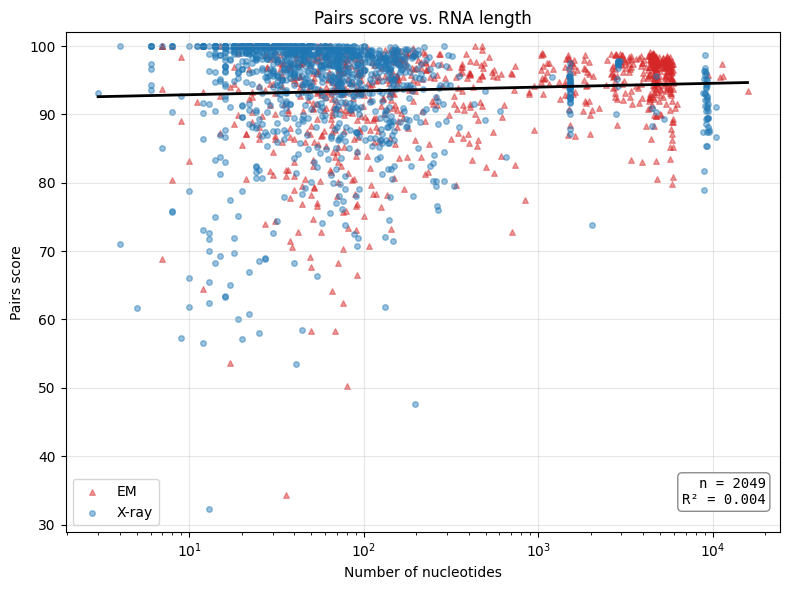

In [4]:
d = df.dropna(subset=['pairs_score', 'n_nucleotides'])
d = d[(d['n_nucleotides'] > 0) & (d['n_pairs'] >= 1)].copy()
log_n = np.log10(d['n_nucleotides'])
colors = {'X-ray': 'tab:blue', 'EM': 'tab:red'}; markers = {'X-ray': 'o', 'EM': '^'}
fig, ax = plt.subplots(figsize=(8, 6))
for method, s in d.groupby('method'):
    if method not in colors: continue
    ax.scatter(s['n_nucleotides'], s['pairs_score'], s=16, alpha=0.45,
               color=colors[method], marker=markers[method], label=method)
slope, intercept = np.polyfit(log_n, d['pairs_score'], 1)
xline = np.logspace(log_n.min(), log_n.max(), 100)
ax.plot(xline, slope*np.log10(xline) + intercept, color='black', lw=2)
r, _ = pearsonr(log_n, d['pairs_score'])
ax.text(0.98, 0.05, f'n = {len(d)}\nR\u00b2 = {r**2:.3f}', transform=ax.transAxes,
        ha='right', va='bottom', family='monospace', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))
ax.set_xscale('log'); ax.set_ylim(top=102); ax.grid(alpha=0.3)
ax.set_xlabel('Number of nucleotides'); ax.set_ylabel('Pairs score')
ax.set_title('Pairs score vs. RNA length'); ax.legend(loc='lower left')
fig.tight_layout(); print('saved', savefig(fig, 'figure3_E_score_vs_nucleotides.png')); plt.show()